2026-08-04 생성형AI 활용을 위한 머신러닝&딥러닝

# KMEANS

In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

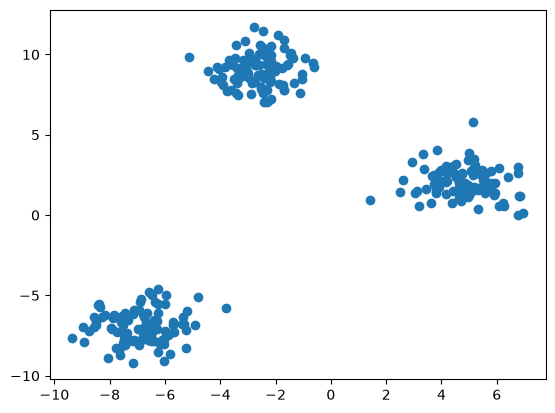

In [27]:
X, y = make_blobs(
    n_samples=300,
    centers=3,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1])

[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]


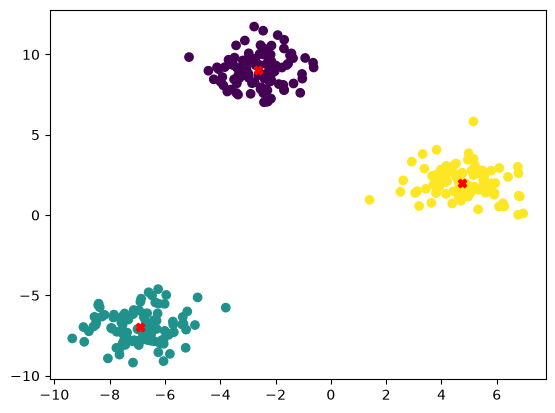

In [36]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

cluster_labels = kmeans.fit_predict(X)

print(kmeans.cluster_centers_)

plt.scatter(X[:, 0], X[:, 1], cmap='viridis', c=cluster_labels)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker='X',
    color='red'
)

In [39]:
result = []
for k in range(1, 10):
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans_temp.fit_predict(X)
    result.append(kmeans_temp.inertia_)

print(result)

[20402.344442926293, 5763.464789461435, 566.8595511244131, 497.033988149521, 428.21421299328415, 375.06592487762447, 308.1983661041825, 272.4057314987481, 234.28072349591133]


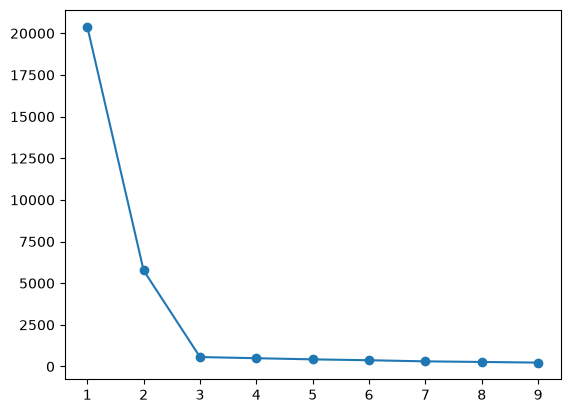

In [41]:
plt.plot(
    range(1, 10), result, marker='o'
)

In [47]:
from sklearn.metrics import silhouette_score, silhouette_samples

sil_score = silhouette_score(X, cluster_labels)
print(sil_score)

sil_values = silhouette_samples(X, cluster_labels)
print(sil_values)

0.8480303059596955
[0.90593228 0.90295138 0.78292932 0.82801009 0.85347199 0.87164904
 0.87660124 0.87599826 0.87967189 0.85542272 0.8185558  0.87259676
 0.74387596 0.84157115 0.90743902 0.87272287 0.87580064 0.72626456
 0.86269038 0.78265318 0.78367684 0.88236857 0.86744598 0.91367619
 0.87177917 0.84973102 0.88991326 0.69411153 0.86247358 0.84701361
 0.85559028 0.86435444 0.88923506 0.81530708 0.84205606 0.84407722
 0.89049865 0.87854612 0.90341598 0.76522292 0.84764565 0.8725714
 0.91062018 0.81940318 0.8287758  0.82800398 0.91293113 0.86613733
 0.9101851  0.81830486 0.87279139 0.85655332 0.90111562 0.76870605
 0.87629642 0.52748913 0.90894375 0.83452366 0.86343982 0.86125249
 0.88918749 0.76979529 0.86487455 0.69836723 0.88372903 0.82959834
 0.85491415 0.88631591 0.8734638  0.86485178 0.85190407 0.85010535
 0.90260065 0.86305493 0.80711153 0.90990924 0.85777116 0.85024895
 0.87568057 0.85626803 0.86869093 0.86376756 0.89694868 0.85592685
 0.86287428 0.88174667 0.87343813 0.75129446

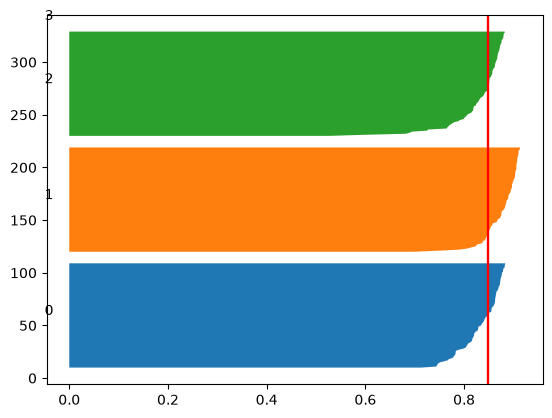

In [48]:
import numpy as np

y_lower = 10

for i in range(4):
    ith_cluster_silhouette_values = sil_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10

    plt.axvline(x=sil_score, color='red')

# 차원 축소 : PCA

In [49]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [50]:
iris = load_iris()

X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_[0])
print(X_pca)

0.7296244541329989
[[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]
 [-2.07563095  1.48917752]
 [-2.44402884  0.0476442 ]
 [-2.23284716  0.22314807]
 [-2.33464048 -1.11532768]
 [-2.18432817 -0.46901356]
 [-2.1663101   1.04369065]
 [-2.32613087  0.13307834]
 [-2.2184509  -0.72867617]
 [-2.6331007  -0.96150673]
 [-2.1987406   1.86005711]
 [-2.26221453  2.68628449]
 [-2.2075877   1.48360936]
 [-2.19034951  0.48883832]
 [-1.898572    1.40501879]
 [-2.34336905  1.12784938]
 [-1.914323    0.40885571]
 [-2.20701284  0.92412143]
 [-2.7743447   0.45834367]
 [-1.81866953  0.08555853]
 [-2.22716331  0.13725446]
 [-1.95184633 -0.62561859]
 [-2.05115137  0.24216355]
 [-2.16857717  0.52714953]
 [-2.13956345  0.31321781]
 [-2.26526149 -0.3377319 ]
 [-2.14012214 -0.50454069]
 [-1.83159477  0.42369507]
 [-2.61494794  1.79357586]
 [-2.44617739  2.15072788]
 [-2.10997488 -0.46020184]
 [-2.2078089  -0.2061074 ]
 [-2.0451

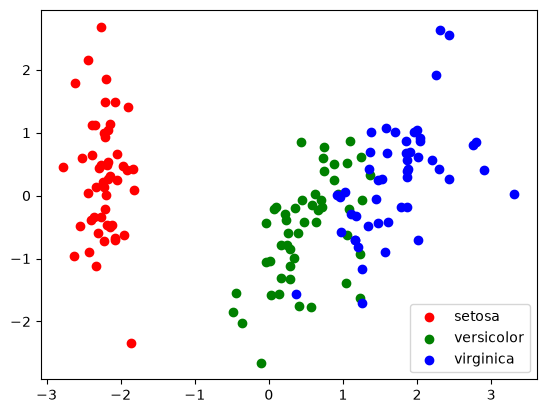

In [51]:
for target, color, label in zip([0, 1, 2], ['red', 'green', 'blue'], iris.target_names):
    plt.scatter(
        X_pca[y == target, 0],
        X_pca[y == target, 1],
        color=color,
        label=label
    )

plt.legend()

# 이상치 탐지 : Isolation Forest

In [55]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

normal_traffic = np.random.normal(loc=50, scale=10, size=(100, 2))
ano_traffic = np.random.uniform(low=100, high=150, size=(10, 2))

traffic_data = np.vstack((normal_traffic, ano_traffic))

traffic_df = pd.DataFrame(traffic_data, columns=['Request Count', 'Response Time'])
traffic_df

,Request Count,Response Time
0,62.959758,47.803613
1,42.527264,37.745477
2,51.392166,59.570891
3,54.075136,61.254338
4,58.354172,69.782690
...,...,...
105,131.149324,149.533488
106,126.871381,121.640705
107,149.684922,135.574963
108,124.799185,121.774843


In [56]:
model = IsolationForest(
    n_estimators=150,
    contamination=0.12,
    random_state=42
)

traffic_df['Anomaly Score'] = model.fit_predict(traffic_df)
traffic_df

,Request Count,Response Time,Anomaly Score
0,62.959758,47.803613,1
1,42.527264,37.745477,1
2,51.392166,59.570891,1
3,54.075136,61.254338,1
4,58.354172,69.782690,1
...,...,...,...
105,131.149324,149.533488,-1
106,126.871381,121.640705,-1
107,149.684922,135.574963,-1
108,124.799185,121.774843,-1


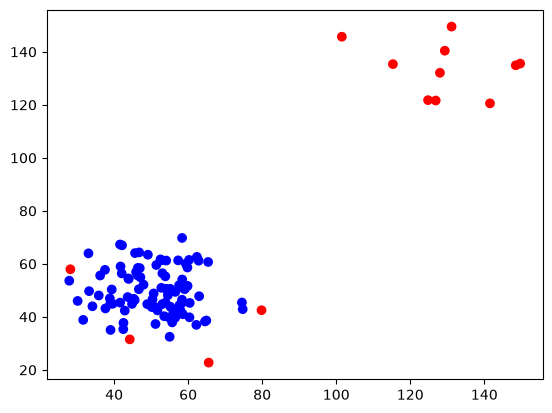

In [60]:
plt.scatter(
    traffic_df['Request Count'],
    traffic_df['Response Time'],
    c=traffic_df['Anomaly Score'].map({1:'blue', -1:'red'})
)

In [61]:
ano_data = traffic_df[traffic_df['Anomaly Score'] == -1]
ano_data

,Request Count,Response Time,Anomaly Score
13,44.226410,31.518562,-1
64,79.815898,42.520647,-1
93,28.178135,57.979468,-1
94,65.546659,22.753702,-1
100,101.512662,145.702074,-1
101,148.485519,134.923658,-1
102,129.320818,140.435368,-1
103,115.309927,135.366326,-1
104,141.525549,120.572622,-1
105,131.149324,149.533488,-1


# DBSCAN

In [68]:
from sklearn.cluster import DBSCAN

normal_traffic = np.random.normal(loc=50, scale=10, size=(100, 2))
ano_traffic = np.random.uniform(low=100, high=150, size=(10, 2))

traffic_data = np.vstack((normal_traffic, ano_traffic))

traffic_df = pd.DataFrame(traffic_data, columns=['Request Count', 'Response Time'])
print(traffic_df)

dbscan = DBSCAN(
    eps=15,
    min_samples=5
)

     Request Count  Response Time
0        64.417742      51.972168
1        48.938047      33.532081
2        47.267523      35.387687
3        36.146659      41.924326
4        62.139053      46.800630
..             ...            ...
105     133.274372     122.926060
106     101.741201     110.476119
107     102.367599     100.923460
108     119.567120     147.957678
109     117.442128     123.219345

[110 rows x 2 columns]


In [69]:
traffic_df['Cluster'] = dbscan.fit_predict(traffic_df)
traffic_df['Anomaly'] = traffic_df['Cluster'].apply(lambda x: 'Anomaly' if x == -1 else 'Nomal')

traffic_df

,Request Count,Response Time,Cluster,Anomaly
0,64.417742,51.972168,0,Nomal
1,48.938047,33.532081,0,Nomal
2,47.267523,35.387687,0,Nomal
3,36.146659,41.924326,0,Nomal
4,62.139053,46.800630,0,Nomal
...,...,...,...,...
105,133.274372,122.926060,-1,Anomaly
106,101.741201,110.476119,-1,Anomaly
107,102.367599,100.923460,-1,Anomaly
108,119.567120,147.957678,-1,Anomaly


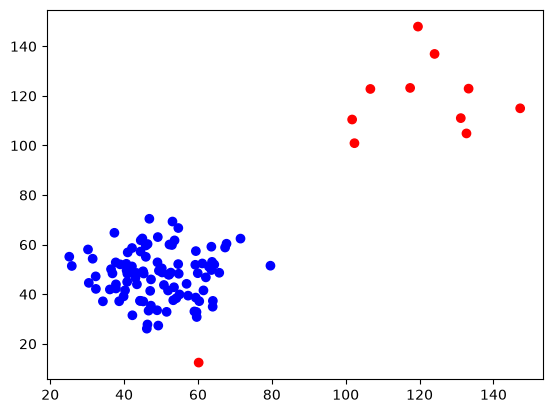

In [70]:
plt.scatter(
    traffic_df['Request Count'],
    traffic_df['Response Time'],
    c=traffic_df['Anomaly'].map({'Nomal':'blue', 'Anomaly':'red'})
)